# A-SCLC

Edit the input path and device parameters, load the measurements, and inspect
the measured current density.
CSV format: `U(V),I(A)` with two numeric columns in that order (volts,
amperes). Raw measurements retain their signs and order.

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from asclc_workflow import run_calculation, export_results
from asclc_plotting import plot_measured_jv, plot_smoothed_jv

## Input and sample parameters

Values from the workbook: MAPbBr3, S2, dark. Replace for your sample.


In [2]:
input_path = project_root / "data/MAPbBr3_S2_dark.csv"

# Experiment (workbook "Experiment" block)
experiment = dict(
    date="27.09.2024",
    sample="S2",
    regime="dark",
    voltage=(3, -3),   # V
    T=299.00,          # K
    T0=273.15,         # K
)

# Material: MAPbBr3 (workbook "Material" block)
material = dict(
    L=6.00e-4,      # m, thickness
    S=7.70e-6,      # m^2, area
    eps_r=25.50,    # relative permittivity
    E_c=-3.36,      # eV, conduction band edge
    E_v=-5.58,      # eV, valence band edge
    E_g=2.22,       # eV, band gap
    m_eff_p=0.305,  # hole effective mass / m_e
    m_eff_e=0.320,  # electron effective mass / m_e
)

trap_profile = "biexponential"   # forced; SI S5

# Numerics. window = points averaged per smoothed point; workbook cell
# Data-calculations!I1 + 1 (currently I1 = 10). trailing_mean at window 11
# reproduces the workbook's smoothed j column to 3 sig figs. See
# docs/ASCLC_guide.md, "Local-slope smoothing window".
numerics = dict(window=11)


In [3]:
device = dict(area=material["S"], voltage_offset=0.0)
result = run_calculation(input_path, device=device)
print(f"Loaded {result.V.size} measurements; "
      f"{(~result.measurements.finite).sum()} nonfinite rows retained.")

Loaded 214 measurements; 0 nonfinite rows retained.


## Measured current density

Measured current density against voltage on logarithmic axes. Nonpositive
readings are kept in the data but cannot appear on a logarithmic axis.

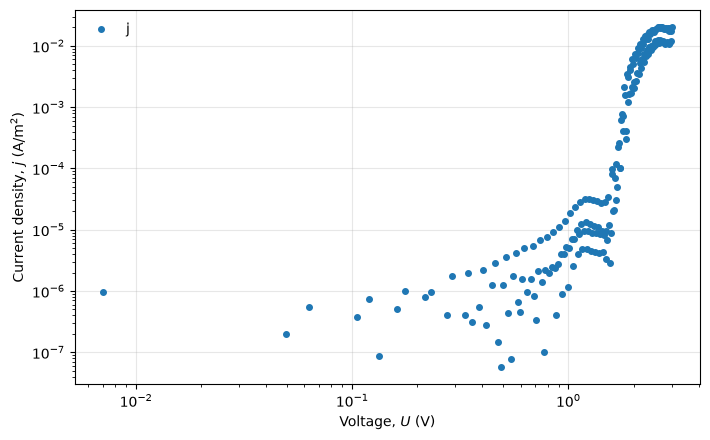

In [4]:
figures = {}
fig, ax = plot_measured_jv(result)
figures["measured_jv"] = fig

## Smoothed current density

A centred `numerics["window"]`-point mean of the current density, drawn over the
raw markers at the same voltages so the two can be compared directly. Points
near either end, where the window would run off the data, have no smoothed
value.

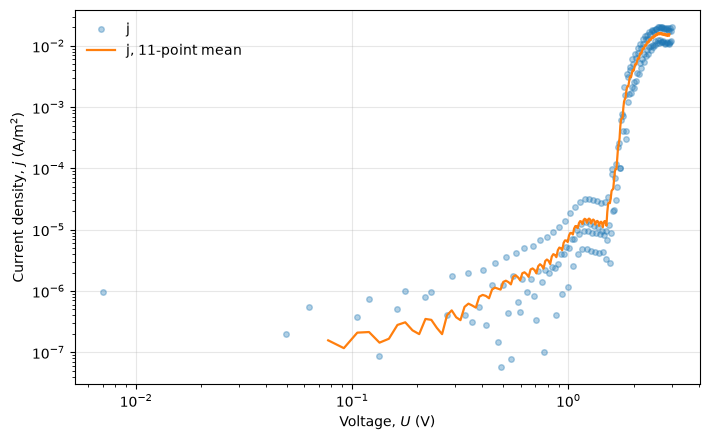

In [5]:
fig_s, ax_s = plot_smoothed_jv(result, window=numerics["window"])
figures["smoothed_jv"] = fig_s

## Export

Save the figure as PNG/PDF/SVG and write the measured CSV to the output
directory.

In [6]:
output_dir = export_results(result, figures, project_root / "outputs")
print(f"Saved {len(figures)} figures and measured data to {output_dir}")

Saved 2 figures and measured data to C:\Work_coding\ASCLC_Pythonized\outputs
